## Sales Forecasting for a Retail Store

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# Sales Forecasting for a Retail Store
data_sales = pd.read_csv("Retail_sales.csv") # Ensure dataset contains relevant features
print(data_sales.columns)
print(data_sales.shape)

Index(['Store ID', 'Product ID', 'Date', 'Units Sold', 'Sales Revenue (USD)',
       'Discount Percentage', 'Marketing Spend (USD)', 'Store Location',
       'Product Category', 'Day of the Week', 'Holiday Effect'],
      dtype='object')
(30000, 11)


In [ ]:
X_sales = data_sales[['Units Sold', 'Discount Percentage', 'Marketing Spend (USD)', 'Day of the Week', 'Holiday Effect']]
X_sales = pd.get_dummies(X_sales, columns=['Day of the Week'],drop_first=True)
y_sales = data_sales['Sales Revenue (USD)']
X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(X_sales, y_sales, test_size=0.2, random_state=1)


In [ ]:
model_sales = LinearRegression()
model_sales.fit(X_train_sales, y_train_sales)


LinearRegression()

Sales Forecast - MSE: 4079467.7237977493
Sales Forecast - R-squared: 0.4146598440628858


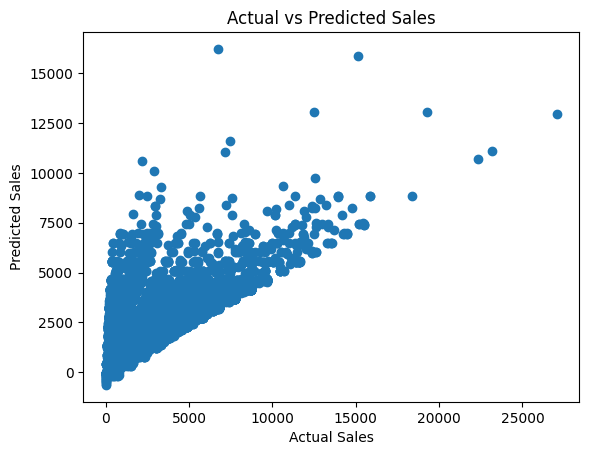

In [ ]:
y_pred_sales = model_sales.predict(X_test_sales)

mse_sales = mean_squared_error(y_test_sales, y_pred_sales)
r2_sales = r2_score(y_test_sales, y_pred_sales)

print(f"Sales Forecast - MSE: {mse_sales}")
print(f"Sales Forecast - R-squared: {r2_sales}")

plt.scatter(y_test_sales, y_pred_sales)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

## Email Spam Detection using Support Vectore Machine (SVM)

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
# Load dataset
df = pd.read_csv("spam.csv",encoding='latin-1')
print(df.columns)
print(df.shape)

df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)
print(df.head())

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
(5572, 5)
     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [2]:

df.columns = ["label", "message"]
# Convert labels to binary (ham = 0, spam = 1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Text Preprocessing
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()
corpus = []
for msg in df['message']:
  msg = re.sub('[^a-zA-Z]', ' ', msg).lower().split()
  msg = [ps.stem(word) for word in msg if word not in stopwords.words('english')]
  corpus.append(" ".join(msg))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
print(corpus[0])
print(df['message'][0])

go jurong point crazi avail bugi n great world la e buffet cine got amor wat
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [4]:
# Convert text into numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(corpus).toarray()
y = df['label'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=1)

# Train SVM Model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)



SVC(kernel='linear')

In [5]:
# Predict and Evaluate
y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9883408071748879
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       976
           1       0.98      0.93      0.95       139

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



## Customer Churn Prediction using (SVM)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")


In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['customerID'])

# Encode categorical variables
label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
  df[col] = label_enc.fit_transform(df[col])

# Define features and target variable
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=1)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM Model
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train, y_train)


SVC(C=1)

In [ ]:

# Predict and Evaluate
y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8133427963094393
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1061
           1       0.66      0.50      0.57       348

    accuracy                           0.81      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## Fraud Detection in Credit Card Transactions

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
# Load dataset
df = pd.read_csv("https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv")



In [ ]:
# Reduce dataset size for faster processing
df = df.sample(frac=0.5, random_state=1)
print(df.shape)
print(df.columns)

(142404, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [ ]:
# Define features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=1)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM Model
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train, y_train)



SVC(C=1)

In [ ]:
# Predict and Evaluate
y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9989466661985184
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28429
           1       1.00      0.42      0.59        52

    accuracy                           1.00     28481
   macro avg       1.00      0.71      0.80     28481
weighted avg       1.00      1.00      1.00     28481

